### 0. Preliminaries
Import necessary packages

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

### 1. Model Setup
Define constant parameters, user functions, and simulation individuals

In [180]:
# Define constant parameters
county_size = 20 # miles
taxi_speed = 20 # miles per hour
base_fare = 3.00 # pounds
per_mile_fare = 2.00 # pounds per mile
petrol_cost = 0.2 # pounds per mile

In [181]:
# Initialise performance statistics
N_D = 0
N_R = 0
T_D = 0
T_R = 0
P = 0
R = 0
T_P = []
T_All = []
T_W = []

driver_ride_counts = {}
driver_idle_time = {}
driver_last_busy_time = {}

In [182]:
def distance(loc1, loc2):
    return np.sqrt((loc1[0] - loc2[0])**2 + (loc1[1] - loc2[1])**2)

def generate_location():
    return (random.uniform(0, county_size), random.uniform(0, county_size))

def travel_time(d_OD):
    mu = d_OD / taxi_speed
    return random.uniform(0.8*mu, 1.2*mu) 

### 2. Simulation

In [183]:
TNOW = 0
Termination = 100 #hrs

EventTypes = ['DriverArrival', 'RiderArrival', 'PickupStart', 
              'Pickup', 'Dropoff', 'RiderAbandonment', 'DriverOffline', 'Termination']
EventCalendar = []

def schedule_event(time, event_type, data=None):
    '''Event scheduler that keeps track of times, event type, and user data (optional)'''
    EventCalendar.append((time,event_type,data))

drivers =[]
idle_drivers=[]
riders = []
waiting_riders=[]

driver_id_counter = 0
rider_id_counter = 0

abandoned_rides = 0

schedule_event(random.expovariate(3), 1)   # 1 = Driver Arrival
schedule_event(random.expovariate(30), 2)  # 2 = Rider Arrival
schedule_event(Termination, 8)             # 8 = Termination

while TNOW < Termination:
    TNEXT, TypeNext, Data = min(EventCalendar, key=lambda x: x[0])
    EventCalendar.remove((TNEXT, TypeNext, Data))

    ## Update Performance Stats Here (Alice)

    TNOW = TNEXT

    # DriverArrival
    if TypeNext == 1:
        driver_id_counter += 1

        # Generate driver location and offline time (initialize other attributes)
        driver = {
            "id": driver_id_counter,
            "location": generate_location(),
            'offline_time': TNOW + random.uniform(5,8),
            'idle': True,
            'active': True,
            'earnings': 0,
            'online_time': TNOW
        }
        drivers.append(driver)
        
        # Schedule offline time
        schedule_event(driver['offline_time'], event_type=7, data = driver)

        # Match driver to waiting rider
        if waiting_riders:
            # match closest waiting rider
            rider = min(waiting_riders, key = lambda r:distance(driver['location'], r['origin']))
            waiting_riders.remove(rider)
            
            # update statuses
            rider['status'] = 'matched'
            driver['idle'] = False
            
            # schedule pickup start
            schedule_event(TNOW, event_type=3, data = (driver, rider)) 
        else:
            idle_drivers.append(driver)
        
        # Schedule next driver arrival
        schedule_event(TNOW + random.expovariate(3), event_type=1)

        # Update performance metrics
        N_D += 1
        driver['online_time'] = TNOW
        driver_ride_counts[driver['id']] = 0
        driver_idle_time[driver['id']] = 0
        driver_last_busy_time[driver['id']] = TNOW

    # RiderArrival
    elif TypeNext == 2: 
        rider_id_counter += 1

        # Generate rider location and patience time (initialize other attributes)
        rider = {
            "id": rider_id_counter,
            "origin": generate_location(),
            'destination': generate_location(),
            'patience_time': random.expovariate(5),
            'status': 'waiting'
        }
        riders.append(rider)
        
        # Match driver to idle driver
        if idle_drivers:
            # match to closest driver
            driver = min(idle_drivers, key = lambda d:distance(d['location'], rider['origin']))
            idle_drivers.remove(driver)

            # update statuses
            rider['status'] = 'matched'
            driver['idle'] = False

            # schedule PickupStart
            schedule_event(TNOW, event_type=3, data = (driver,rider))
        else:
            waiting_riders.append(rider)

            #schedule patience deadline for waiting rider
            schedule_event(TNOW+rider['patience_time'], event_type=6, data = rider)
        
        # schedule next rider arrival
        schedule_event(TNOW + random.expovariate(30), event_type=2)

        # Update performance metrics
        N_R += 1
        rider['arrival_time'] = TNOW
        T_P.append(rider['patience_time'])

    # PickupStart
    elif TypeNext == 3:
        driver,rider = Data

        if not driver['active']:
            continue
        
        # Calculate actual travel time 
        d1 = distance(driver['location'],rider['origin'])
        t1 = travel_time(d1)

        # Schedule Pickup event
        schedule_event(TNOW + t1, event_type=4, data = (driver,rider,d1))

        # Update performance metrics
        waiting_time = TNOW - rider['arrival_time']  # time waited between rider arrival and matching
        T_W.append(waiting_time)
        T_All.append(waiting_time)
        driver_ride_counts[driver['id']] += 1
        driver_idle_time[driver['id']] += TNOW - driver_last_busy_time[driver['id']]
        driver_last_busy_time[driver['id']] = TNOW
    
    # Pickup
    elif TypeNext == 4:
        driver, rider, d1 = Data
        
        # Calculate actual travel time
        d2 = distance(rider['origin'], rider['destination'])
        t2 = travel_time(d2)

        # Schedule Dropoff
        schedule_event(TNOW + t2, event_type=5, data = (driver,rider,d1,d2,t2))

    # Dropoff
    elif TypeNext == 5:
        driver, rider, d1, d2,t2 = Data

        # update rider status
        rider["status"] = "dropped-off"

        # calculate driver earnings
        rider_fare = base_fare + per_mile_fare * d2
        driver_cost = petrol_cost*(d1+d2)
        driver_profit = rider_fare - driver_cost
        driver['earnings'] += driver_profit      # changed this to make it cumulative profit
        
        # Update driver information
        driver['location'] = rider['destination']
        driver['idle'] = True

        # Check if driver is meant to be offline now
        if TNOW >= driver['offline_time']:
            driver['active'] = False
        else:
            if waiting_riders:
                next_rider = min(waiting_riders,
                                 key=lambda r: distance(driver['location'], r['origin']))
                waiting_riders.remove(next_rider)
                next_rider['status'] = 'matched'
                driver['idle'] = False
                # schedule next pickup if driver gets matched to a new rider
                schedule_event(TNOW, event_type=3, data = (driver, next_rider))
            else:
                idle_drivers.append(driver)

        # Update performance metrics
        R += 1
        T_R += t2  
        P += driver_profit
        driver_last_busy_time[driver['id']] = TNOW
    
    # RiderAbandonment
    elif TypeNext == 6:
        rider = Data

        # remove abandonded riders and update status
        if rider['status'] == 'waiting':
            waiting_riders.remove(rider)
            rider["status"] = "abandoned"
            abandoned_rides += 1

            # Update performance metrics
            T_All.append(rider['patience_time'])
    
    # DriverOffline
    elif TypeNext == 7:
        driver = Data
        
        # remove offline drivers and update status
        if driver["active"] and driver["idle"]:
            driver["active"] = False
            if driver in idle_drivers:
                idle_drivers.remove(driver)

        # Update performance metrics
        T_D += TNOW - driver['online_time']
        driver_idle_time[driver['id']] += TNOW - driver_last_busy_time[driver['id']]

    else:
        # Update performance metrics
        for driver in drivers:
            if driver['active']:
                T_D += TNOW - driver['online_time']
                
                if driver['idle']:
                    driver_idle_time[driver['id']] += TNOW - driver_last_busy_time[driver['id']]


        break


In [184]:
print(T_P[20:30])
print(T_All[20:30])
print(len(T_P))
print(len(T_All))

[0.0759819747407238, 0.057772018502110646, 0.1076398997790611, 0.21724713371113494, 0.10024950896054607, 0.3918873296396986, 0.7182768272635921, 0.013479674155568938, 0.1834965414793853, 0.17822942650582876]
[0.3796648007491269, 0.1306995743022379, 0.10024950896054607, 0.16911223280549625, 0.3075676212747205, 0.013479674155568938, 0.05375641671529552, 0.1834965414793853, 0.04324753113312141, 0.3918873296396986]
2909
2909


### 2. Analyse Simulation Results

#### Compute Final Performance Metrics

In [185]:
# Overall metrics

abandonment_rate = (N_R - R) / N_R

avg_wait_served = np.mean(T_W)
avg_wait_all = np.mean(T_All)

avg_earnings_per_hour = P / T_D 

total_idle_time = T_D - T_R
avg_idle_per_ride = total_idle_time / R 
idle_proportion = total_idle_time / T_D 

ongoing_rides = sum(1 for event in EventCalendar if event[1] == 5)

# Individual driver metrics

driver_profits = []
driver_rides = []
driver_idle = []
driver_online = []
driver_idle_per_ride = []
driver_working_ratio = []

for driver in drivers:
    d_ID = driver['id']
    online_time = 0
    idle_time = 0
    rides = driver_ride_counts.get(d_ID, 0)
    
    # compute idle time
    if d_ID in driver_idle_time:
        idle_time = driver_idle_time[d_ID]
    
    # compute online time
    if 'online_time' in driver:
        if driver['active']:
            online_time = Termination - driver['online_time']
        else:
            online_time = driver['offline_time'] - driver['online_time']
    
    profit = driver['earnings']
    
    driver_profits.append(profit)
    driver_rides.append(rides)
    driver_idle.append(idle_time)
    driver_online.append(online_time)
    
    if rides > 0:
        driver_idle_per_ride.append(idle_time / rides)
    else:
        driver_idle_per_ride.append(0)
    
    if online_time > 0:
        driver_working_ratio.append((online_time - idle_time) / online_time)
    else:
        driver_working_ratio.append(0)

# Print metrics

print("-------------Overall Metrics-------------")
print(f"Total Riders: {N_R}")
print(f"Completed Rides: {R}")
print(f"Abandonment Rate: {abandonment_rate:.2%}")
print(f"Rides still in progress at termination: {ongoing_rides}")
print(f"Average Waiting Time (served): {avg_wait_served:.3f} hours")
print(f"Average Waiting Time (all): {avg_wait_all:.3f} hours")
print(f"Average Earnings per Driver-Hour: £{avg_earnings_per_hour:.2f}")
print(f"Idle Proportion of System Time: {idle_proportion:.2%}")
print(f"Average Idle Time per Ride (system-wide): {avg_idle_per_ride:.3f} hours")

print("\n-------------Per-Driver Metrics-------------")
print(f"Average Profit per Driver: £{np.mean(driver_profits):.2f}")
print(f"Average Rides per Driver: {np.mean(driver_rides):.2f}")
print(f"Standard Deviation Rides per Driver: {np.std(driver_rides):.2f}")
print(f"Average Working Ratio: {np.mean(driver_working_ratio):.2%}")

-------------Overall Metrics-------------
Total Riders: 2909
Completed Rides: 2110
Abandonment Rate: 27.47%
Rides still in progress at termination: 9
Average Waiting Time (served): 0.036 hours
Average Waiting Time (all): 0.051 hours
Average Earnings per Driver-Hour: £22.30
Idle Proportion of System Time: 42.30%
Average Idle Time per Ride (system-wide): 0.378 hours

-------------Per-Driver Metrics-------------
Average Profit per Driver: £142.91
Average Rides per Driver: 7.24
Standard Deviation Rides per Driver: 1.61
Average Working Ratio: 86.46%


#### Metric plots

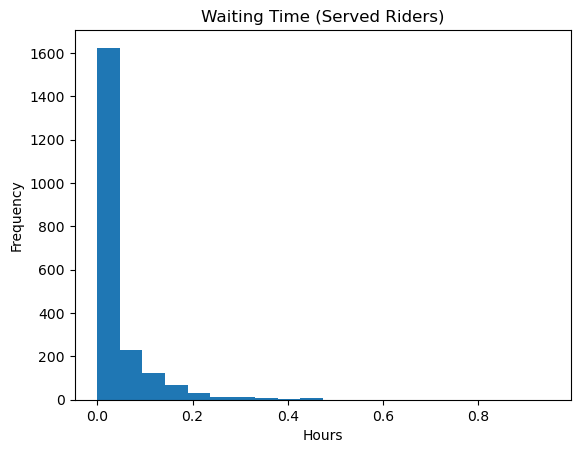

In [186]:
plt.figure()
plt.hist(T_W, bins=20)
plt.title("Waiting Time (Served Riders)")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

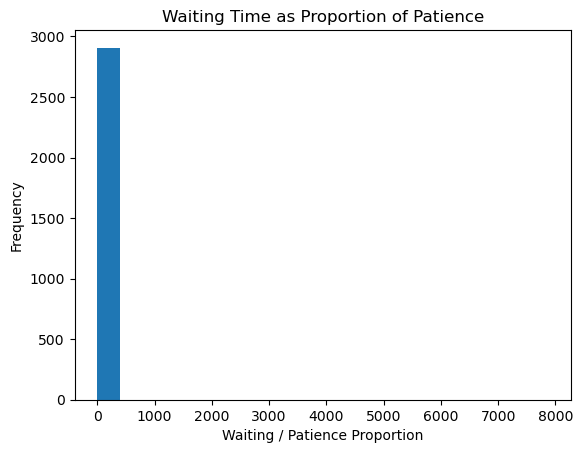

In [187]:
wait_ratios = np.array(T_All) / np.array(T_P)

plt.figure()
plt.hist(wait_ratios, bins=20)
plt.title("Waiting Time as Proportion of Patience")
plt.xlabel("Waiting / Patience Proportion")
plt.ylabel("Frequency")
plt.show()

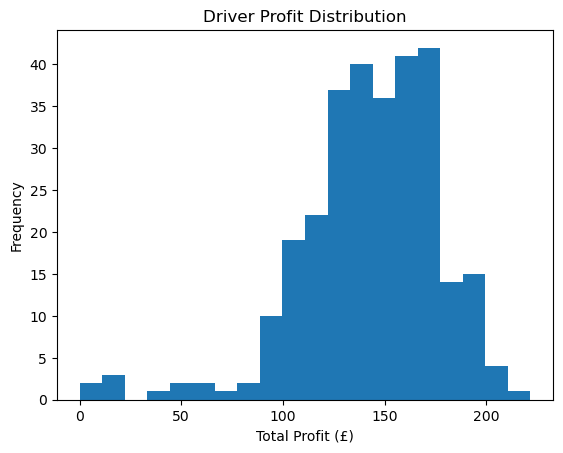

In [188]:
plt.figure()
plt.hist(driver_profits, bins=20)
plt.title("Driver Profit Distribution")
plt.xlabel("Total Profit (£)")
plt.ylabel("Frequency")
plt.show()

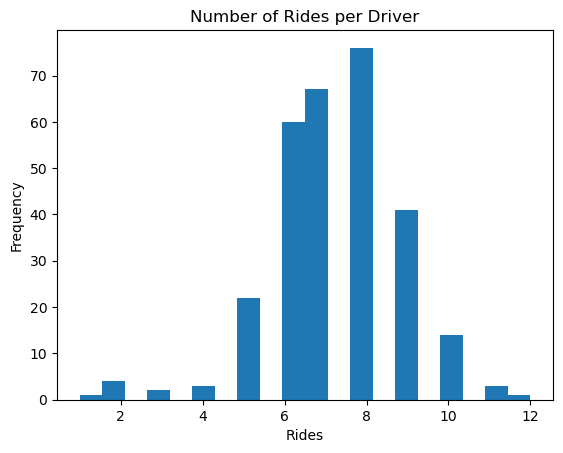

In [189]:
plt.figure()
plt.hist(driver_rides, bins=20)
plt.title("Number of Rides per Driver")
plt.xlabel("Rides")
plt.ylabel("Frequency")
plt.show()

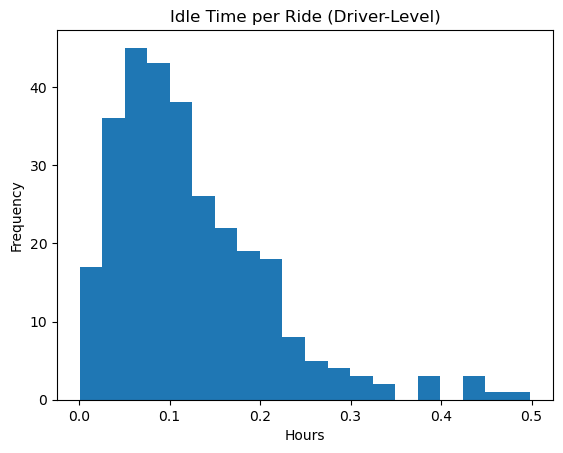

In [190]:
plt.figure()
plt.hist(driver_idle_per_ride, bins=20)
plt.title("Idle Time per Ride (Driver-Level)")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

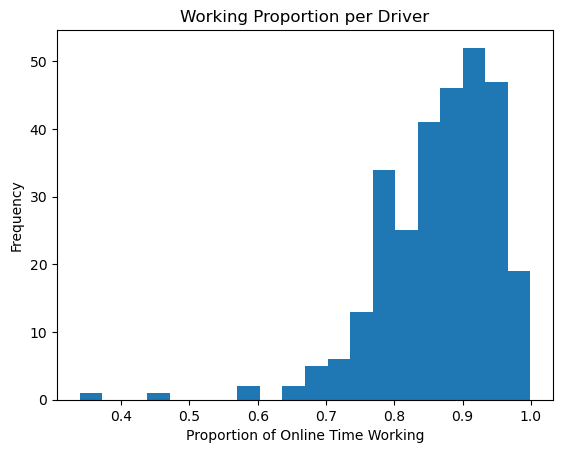

In [191]:
plt.figure()
plt.hist(driver_working_ratio, bins=20)
plt.title("Working Proportion per Driver")
plt.xlabel("Proportion of Online Time Working")
plt.ylabel("Frequency")
plt.show()

### 3. Manually Simulate with Given Data

The `riders.xlsx` and `drivers.xlsx` data sets are provided from the project assignment page. 

In [192]:
riders_df = pd.read_excel('riders.xlsx')
drivers_df = pd.read_excel('drivers.xlsx')